# Clustering Model Comparison for Typhoon Impact Profiling

## Overview
This notebook performs a **comprehensive comparison of multiple clustering algorithms** to identify the optimal model for classifying typhoon impact events in the Philippines. The comparison evaluates **12 models (6 baseline + 6 Optuna-optimized)** using standard clustering metrics (Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index) to determine the best-performing algorithm and measure the impact of hyperparameter optimization.

---

## Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                    CLUSTERING MODEL COMPARISON PIPELINE                         │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   INPUT     │───▶│   PREPROCESS │───▶│     PCA     │───▶│  MULTI-MODEL    │  │
│  │   DATA      │    │   & SCALE    │    │  REDUCTION  │    │   CLUSTERING    │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └────────┬────────┘  │
│                                                                      │          │
│                    ┌─────────────────────────────────────────────────┘          │
│                    ▼                                                            │
│  ┌──────────────────────────────────────────────────────────────────────────┐   │
│  │              BASELINE + OPTUNA-OPTIMIZED CLUSTERING MODELS              │   │
│  │  ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ ┌─────────┐ │   │
│  │  │ KMeans  │ │ DBSCAN  │ │  Agglo  │ │  Agglo  │ │   GMM   │ │   GMM   │ │   │
│  │  │Base+Opt │ │Base+Opt │ │  Ward   │ │Complete │ │  Full   │ │  Diag   │ │   │
│  │  │         │ │         │ │Base+Opt │ │Base+Opt │ │Base+Opt │ │Base+Opt │ │   │
│  │  └─────────┘ └─────────┘ └─────────┘ └─────────┘ └─────────┘ └─────────┘ │   │
│  └──────────────────────────────────────────────────────────────────────────┘   │
│                                    │                                            │
│                                    ▼                                            │
│  ┌─────────────┐    ┌──────────────┐    ┌─────────────┐    ┌─────────────────┐  │
│  │   OUTPUT    │◀───│   RANKING    │◀───│  METRICS    │◀───│  VISUALIZATION  │  │
│  │   REPORT    │    │  & SELECTION │    │  EVALUATION │    │   COMPARISON    │  │
│  └─────────────┘    └──────────────┘    └─────────────┘    └─────────────────┘  │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Input

| File | Description |
|------|-------------|
| `data/typhoon_impact_with_extreme_weather.csv` | Preprocessed typhoon impact dataset containing meteorological data, damage metrics, and affected population statistics |

### Input Features:
- **Impact Metrics**: `Families`, `Person`, `Dead`, `Injured/Ill`, `Missing`, `Totally`, `Partially`, `Cost`
- **Weather Data**: `Max_Sustained_Wind_kph`, `Max_24hr_Rainfall_mm`, `Total_Storm_Rainfall_mm`, `Min_Pressure_hPa`
- **Temporal Data**: `Duration_in_PAR_Hours`
- **Categorical**: `Region`, `Typhoon_Type`

---

## Output

| Output | Description |
|--------|-------------|
| Model Comparison Table | Side-by-side metrics for all 12 models (baseline + optimized) |
| 2D/3D Visualizations | PCA projections showing cluster assignments for each model |
| Final Ranking | Combined normalized score ranking of all models |
| Best Model Recommendation | Optimal algorithm based on evaluation metrics |
| Optimization Impact Analysis | Performance improvement from Optuna optimization |

---

## Models Compared (12 Total: 6 Baseline + 6 Optuna-Optimized, All Targeting 3 Clusters)

| # | Model | Type | Configuration |
|---|-------|------|---------------|
| 1 | **KMeans (Baseline)** | Centroid-based | Default parameters, **fixed 3 clusters** |
| 2 | **KMeans (Optuna)** | Centroid-based | Optuna-optimized (`init`, `n_init`, `max_iter`), **fixed 3 clusters** |
| 3 | **DBSCAN (Baseline)** | Density-based | Default parameters (eps=0.5, min_samples=5), **variable clusters** |
| 4 | **DBSCAN (Optuna)** | Density-based | Optuna-optimized **targeting 3 clusters** |
| 5 | **Agglomerative Ward (Baseline)** | Hierarchical | Ward linkage, **fixed 3 clusters** |
| 6 | **Agglomerative Ward (Optuna)** | Hierarchical | Ward linkage, **fixed 3 clusters** (same as baseline) |
| 7 | **Agglomerative Complete (Baseline)** | Hierarchical | Complete linkage, euclidean metric, **fixed 3 clusters** |
| 8 | **Agglomerative Complete (Optuna)** | Hierarchical | Optuna-optimized metric, **fixed 3 clusters** |
| 9 | **GMM Full (Baseline)** | Probabilistic | Full covariance, default parameters, **fixed 3 clusters** |
| 10 | **GMM Full (Optuna)** | Probabilistic | Optuna-optimized (`n_init`, `max_iter`, `reg_covar`, `init_params`), **fixed 3 clusters** |
| 11 | **GMM Diag (Baseline)** | Probabilistic | Diagonal covariance, default parameters, **fixed 3 clusters** |
| 12 | **GMM Diag (Optuna)** | Probabilistic | Optuna-optimized (`n_init`, `max_iter`, `reg_covar`, `init_params`), **fixed 3 clusters** |

---

## Evaluation Metrics

| Metric | Description | Optimal Value |
|--------|-------------|---------------|
| **Silhouette Score** | Measures cluster cohesion and separation | Higher is better (-1 to 1) |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster variance | Higher is better |
| **Davies-Bouldin Index** | Average similarity between clusters | Lower is better |
| **Combined Score** | Normalized weighted combination of all metrics | Higher is better |

---

## Pipeline Steps

1. **Data Loading & Preprocessing**
   - Load typhoon impact dataset
   - Drop irrelevant columns
   - Encode categorical variables (Region, Typhoon Type)

2. **Feature Scaling**
   - Apply StandardScaler for normalization

3. **Dimensionality Reduction (PCA)**
   - Reduce features while retaining 95% variance
   - Generate 2D and 3D visualizations

4. **Multi-Model Training (Optuna-Optimized)**
   - Train all 6 clustering models with Optuna hyperparameter optimization
   - All models configured for exactly 3 clusters

5. **Metrics Evaluation**
   - Calculate Silhouette, Calinski-Harabasz, Davies-Bouldin scores
   - Record execution time and cluster counts

6. **Visualization Comparison**
   - 2D PCA scatter plots for all models (3x2 grid)
   - 3D PCA scatter plots for all models (3x2 grid)

7. **Final Ranking**
   - Normalize all metrics to 0-1 scale
   - Calculate combined score
   - Rank models and recommend best performer

---

## Dependencies

```python
pandas, numpy, scikit-learn, optuna, xgboost, matplotlib, seaborn
```

In [67]:
# Core data manipulation and numerical libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn components
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN

# Hyperparameter optimization
import optuna

# Surrogate model 
import xgboost as xgb

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [68]:
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Typhoon Name             1776 non-null   object 
 1   Year                     1776 non-null   int64  
 2   Region                   1776 non-null   int64  
 3   Province                 1776 non-null   object 
 4   City/Municipality        1776 non-null   object 
 5   Families                 1776 non-null   int64  
 6   Person                   1776 non-null   int64  
 7   Brgy                     1776 non-null   int64  
 8   Dead                     1776 non-null   int64  
 9   Injured/Ill              1776 non-null   int64  
 10  Missing                  1776 non-null   int64  
 11  Totally                  1776 non-null   int64  
 12  Partially                1776 non-null   int64  
 13  Total                    1776 non-null   int64  
 14  Quantity                

In [70]:
df.isnull().sum()

Typhoon Name               0
Year                       0
Region                     0
Province                   0
City/Municipality          0
Families                   0
Person                     0
Brgy                       0
Dead                       0
Injured/Ill                0
Missing                    0
Totally                    0
Partially                  0
Total                      0
Quantity                   0
Cost                       0
Nearest_Station            0
Station_Province           0
Distance_km                0
PAR_START                  0
PAR_END                    0
Duration_in_PAR_Hours      0
Max_Sustained_Wind_kph     0
Typhoon_Type               0
Max_24hr_Rainfall_mm       0
Total_Storm_Rainfall_mm    0
Min_Pressure_hPa           0
Weather_Station_Mapped     0
Weather_Records_Found      0
Weather_Days_Covered       0
dtype: int64

In [71]:
df.columns

Index(['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality',
       'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing',
       'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station',
       'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END',
       'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type',
       'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa',
       'Weather_Station_Mapped', 'Weather_Records_Found',
       'Weather_Days_Covered'],
      dtype='object')

In [72]:
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [73]:
df.drop(columns=['Quantity', 'PAR_START', 'PAR_END', 'Weather_Days_Covered', 'Total', 'Weather_Station_Mapped', 'Station_Province', 'Nearest_Station', 'Year', 'Typhoon Name', 'City/Municipality', 'Province', 'Distance_km'], inplace=True)
df.head()

,Region,Families,Person,Brgy,Dead,Injured/Ill,Missing,Totally,Partially,Cost,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Records_Found
0,2,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,STY,25.6,39.00,977.1,6
1,2,968,3028,5,0,0,0,0,0,494592.00,133.0,195,STY,20.3,32.71,1000.5,6
2,2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,STY,25.6,39.00,977.1,6
3,2,575,1792,4,0,0,0,0,0,291082.96,133.0,195,STY,25.6,39.00,977.1,6
4,2,575,1955,6,0,0,0,0,0,296521.75,133.0,195,STY,25.6,39.00,977.1,6


In [74]:
df.columns = df.columns.str.lower()

In [75]:
df.columns

Index(['region', 'families', 'person', 'brgy', 'dead', 'injured/ill',
       'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours',
       'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm',
       'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found'],
      dtype='object')

In [76]:
df['typhoon_type'].unique()

array(['STY', 'TY', 'STS', 'TD', 'TS'], dtype=object)

## Data Transformation

In [ ]:
# Convert 'region' column to object type
df['region'] = df['region'].astype('object')

# Perform one-hot encoding for 'region' and convert to int (0/1)
region_encoded = pd.get_dummies(df['region'], prefix='region').astype(int)

# Map 'typhoon_type' to the specified labels
typhoon_type_mapping = {'STY': 4, 'TY': 3, 'STS': 2, 'TS': 1, 'TD': 0}
df['typhoon_type'] = df['typhoon_type'].map(typhoon_type_mapping)

# Concatenate the one-hot encoded 'region' columns back to the dataframe
df = pd.concat([df, region_encoded], axis=1)

# Drop the original 'region' column as it's now encoded
df.drop(columns=['region'], inplace=True)

df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


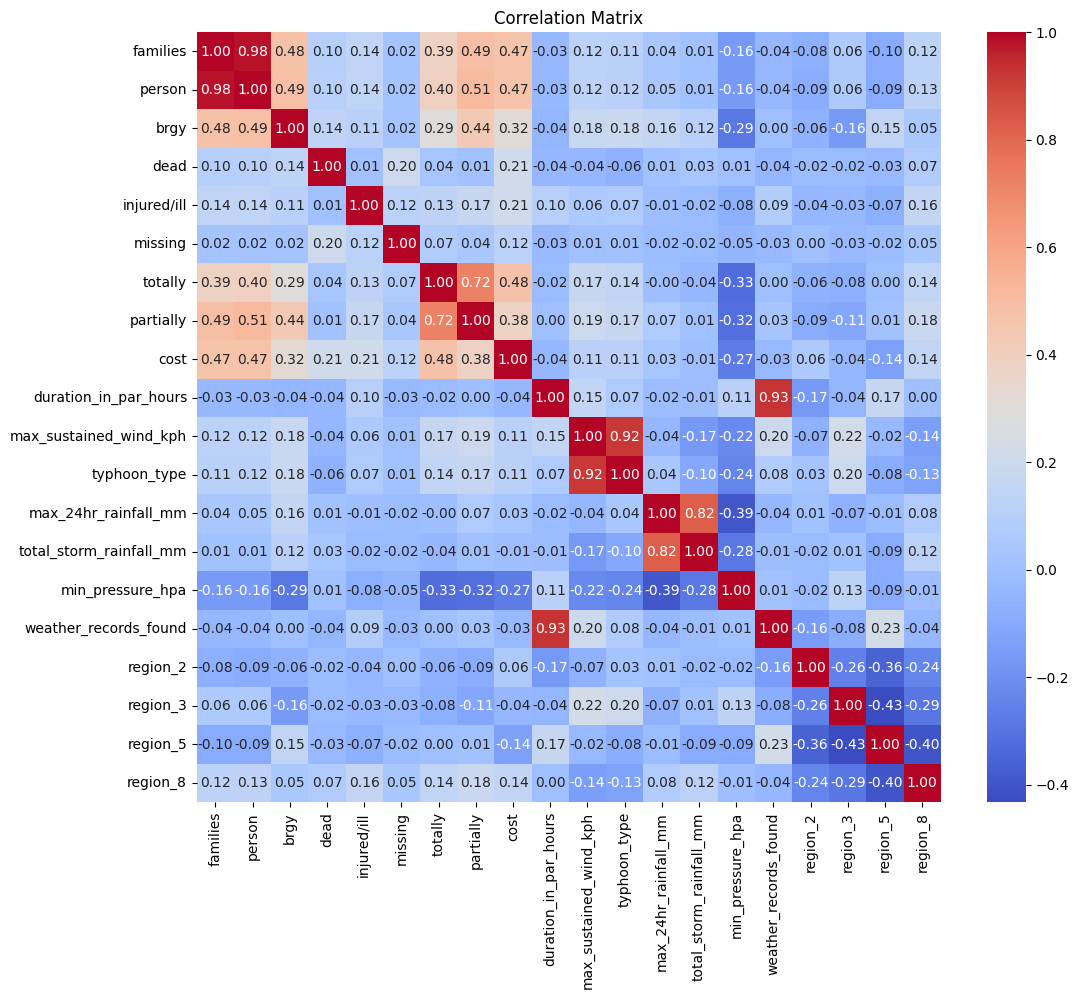

In [78]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [79]:
df.drop(columns=['weather_records_found'], inplace=True)

## PCA Generalization Functions
Functions for performing Principal Component Analysis on the typhoon impact dataset.

In [80]:
def prepare_pca_features(input_dataframe: pd.DataFrame, categorical_columns: list = None) -> tuple:
    """
    Prepare features for PCA by separating numerical and categorical columns.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        The input dataframe containing features
    categorical_columns : list, optional
        List of categorical column names. If None, auto-detects object dtype columns.
    
    Returns:
    --------
    tuple: (numerical_features_df, categorical_features_df, numerical_column_names)
    """
    if categorical_columns is None:
        categorical_columns = input_dataframe.select_dtypes(include=['object']).columns.tolist()
    
    numerical_column_names = [col for col in input_dataframe.columns if col not in categorical_columns]
    
    numerical_features_df = input_dataframe[numerical_column_names].copy()
    categorical_features_df = input_dataframe[categorical_columns].copy() if categorical_columns else pd.DataFrame()
    
    return numerical_features_df, categorical_features_df, numerical_column_names


def scale_numerical_features(numerical_features_df: pd.DataFrame) -> tuple:
    """
    Scale numerical features using StandardScaler.
    
    Parameters:
    -----------
    numerical_features_df : pd.DataFrame
        DataFrame containing only numerical features
    
    Returns:
    --------
    tuple: (scaled_features_array, fitted_scaler_object)
    """
    feature_scaler_object = StandardScaler()
    scaled_features_array = feature_scaler_object.fit_transform(numerical_features_df)
    
    return scaled_features_array, feature_scaler_object


def perform_pca_analysis(
    scaled_features_array: np.ndarray,
    n_components: int = None,
    variance_threshold: float = 0.95
) -> tuple:
    """
    Perform PCA analysis on scaled features.
    
    Parameters:
    -----------
    scaled_features_array : np.ndarray
        Scaled numerical features array
    n_components : int, optional
        Number of components to keep. If None, uses variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold to determine n_components if n_components is None.
    
    Returns:
    --------
    tuple: (pca_transformed_array, fitted_pca_object, explained_variance_ratios)
    """
    # First fit PCA to determine optimal components if not specified
    if n_components is None:
        preliminary_pca_object = PCA()
        preliminary_pca_object.fit(scaled_features_array)
        cumulative_variance_array = np.cumsum(preliminary_pca_object.explained_variance_ratio_)
        n_components = np.argmax(cumulative_variance_array >= variance_threshold) + 1
        del preliminary_pca_object  # Clean up to avoid memory leak
    
    # Perform final PCA with determined number of components
    final_pca_object = PCA(n_components=n_components)
    pca_transformed_array = final_pca_object.fit_transform(scaled_features_array)
    explained_variance_ratios = final_pca_object.explained_variance_ratio_
    
    return pca_transformed_array, final_pca_object, explained_variance_ratios


def create_pca_dataframe(
    pca_transformed_array: np.ndarray,
    n_components: int
) -> pd.DataFrame:
    """
    Create a DataFrame from PCA transformed array with proper column names.
    
    Parameters:
    -----------
    pca_transformed_array : np.ndarray
        Array of PCA transformed features
    n_components : int
        Number of PCA components
    
    Returns:
    --------
    pd.DataFrame: DataFrame with PCA components as columns
    """
    pca_column_names = [f'PC{i+1}' for i in range(n_components)]
    pca_features_df = pd.DataFrame(pca_transformed_array, columns=pca_column_names)
    
    return pca_features_df


def plot_pca_variance_explanation(
    fitted_pca_object: PCA,
    figure_title: str = 'PCA Variance Explanation'
) -> None:
    """
    Plot the explained variance ratio for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    figure_title : str
        Title for the plot
    """
    variance_ratios_array = fitted_pca_object.explained_variance_ratio_
    cumulative_variance_array = np.cumsum(variance_ratios_array)
    n_components_count = len(variance_ratios_array)
    
    pca_variance_fig, pca_variance_axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Individual variance plot
    pca_variance_axes[0].bar(range(1, n_components_count + 1), variance_ratios_array, alpha=0.7, color='steelblue')
    pca_variance_axes[0].set_xlabel('Principal Component')
    pca_variance_axes[0].set_ylabel('Explained Variance Ratio')
    pca_variance_axes[0].set_title('Individual Explained Variance')
    pca_variance_axes[0].set_xticks(range(1, n_components_count + 1))
    
    # Cumulative variance plot
    pca_variance_axes[1].plot(range(1, n_components_count + 1), cumulative_variance_array, 'bo-', linewidth=2, markersize=8)
    pca_variance_axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    pca_variance_axes[1].set_xlabel('Number of Components')
    pca_variance_axes[1].set_ylabel('Cumulative Explained Variance')
    pca_variance_axes[1].set_title('Cumulative Explained Variance')
    pca_variance_axes[1].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].legend()
    pca_variance_axes[1].grid(True, alpha=0.3)
    
    pca_variance_fig.suptitle(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Clean up
    plt.close(pca_variance_fig)


def get_pca_feature_loadings(
    fitted_pca_object: PCA,
    feature_names_list: list
) -> pd.DataFrame:
    """
    Get the feature loadings (component weights) for each PCA component.
    
    Parameters:
    -----------
    fitted_pca_object : PCA
        Fitted PCA object
    feature_names_list : list
        List of original feature names
    
    Returns:
    --------
    pd.DataFrame: DataFrame with feature loadings for each component
    """
    n_components_count = fitted_pca_object.n_components_
    component_names_list = [f'PC{i+1}' for i in range(n_components_count)]
    
    feature_loadings_df = pd.DataFrame(
        fitted_pca_object.components_.T,
        columns=component_names_list,
        index=feature_names_list
    )
    
    return feature_loadings_df


def run_complete_pca_pipeline(
    input_dataframe: pd.DataFrame,
    n_components: int = None,
    variance_threshold: float = 0.95,
    categorical_columns: list = None,
    show_plots: bool = True,
    return_loadings: bool = True
) -> dict:
    """
    Run the complete PCA pipeline on the input dataframe.
    
    Parameters:
    -----------
    input_dataframe : pd.DataFrame
        Input dataframe with features
    n_components : int, optional
        Number of PCA components. If None, auto-determined by variance_threshold.
    variance_threshold : float, default=0.95
        Cumulative variance threshold for auto-determining n_components
    categorical_columns : list, optional
        List of categorical column names to exclude from PCA
    show_plots : bool, default=True
        Whether to display variance explanation plots
    return_loadings : bool, default=True
        Whether to include feature loadings in the result
    
    Returns:
    --------
    dict: Dictionary containing:
        - 'pca_dataframe': DataFrame with PCA components
        - 'pca_object': Fitted PCA object
        - 'scaler_object': Fitted StandardScaler object
        - 'explained_variance': Array of explained variance ratios
        - 'total_variance_explained': Total variance explained by components
        - 'feature_loadings': DataFrame of feature loadings (if return_loadings=True)
        - 'numerical_features': List of numerical feature names used
    """
    # Step 1: Prepare features
    numerical_features_df, categorical_features_df, numerical_column_names = prepare_pca_features(
        input_dataframe, categorical_columns
    )
    
    print(f"Numerical features for PCA: {len(numerical_column_names)}")
    print(f"Features: {numerical_column_names}")
    
    # Step 2: Scale features
    scaled_features_array, feature_scaler_object = scale_numerical_features(numerical_features_df)
    
    # Step 3: Perform PCA
    pca_transformed_array, fitted_pca_object, explained_variance_ratios = perform_pca_analysis(
        scaled_features_array, n_components, variance_threshold
    )
    
    actual_n_components = fitted_pca_object.n_components_
    total_variance_explained = np.sum(explained_variance_ratios)
    
    print(f"\nPCA Results:")
    print(f"Number of components: {actual_n_components}")
    print(f"Total variance explained: {total_variance_explained:.4f} ({total_variance_explained*100:.2f}%)")
    
    # Step 4: Create PCA DataFrame
    pca_features_df = create_pca_dataframe(pca_transformed_array, actual_n_components)
    
    # Step 5: Plot variance explanation
    if show_plots:
        plot_pca_variance_explanation(fitted_pca_object, 'Typhoon Impact Data - PCA Variance Explanation')
    
    # Prepare result dictionary
    pca_result_dict = {
        'pca_dataframe': pca_features_df,
        'pca_object': fitted_pca_object,
        'scaler_object': feature_scaler_object,
        'explained_variance': explained_variance_ratios,
        'total_variance_explained': total_variance_explained,
        'numerical_features': numerical_column_names
    }
    
    # Step 6: Get feature loadings if requested
    if return_loadings:
        feature_loadings_df = get_pca_feature_loadings(fitted_pca_object, numerical_column_names)
        pca_result_dict['feature_loadings'] = feature_loadings_df
    
    # Clean up intermediate variables
    del scaled_features_array, pca_transformed_array
    
    return pca_result_dict

Numerical features for PCA: 19
Features: ['families', 'person', 'brgy', 'dead', 'injured/ill', 'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours', 'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa', 'region_2', 'region_3', 'region_5', 'region_8']

PCA Results:
Number of components: 13
Total variance explained: 0.9515 (95.15%)


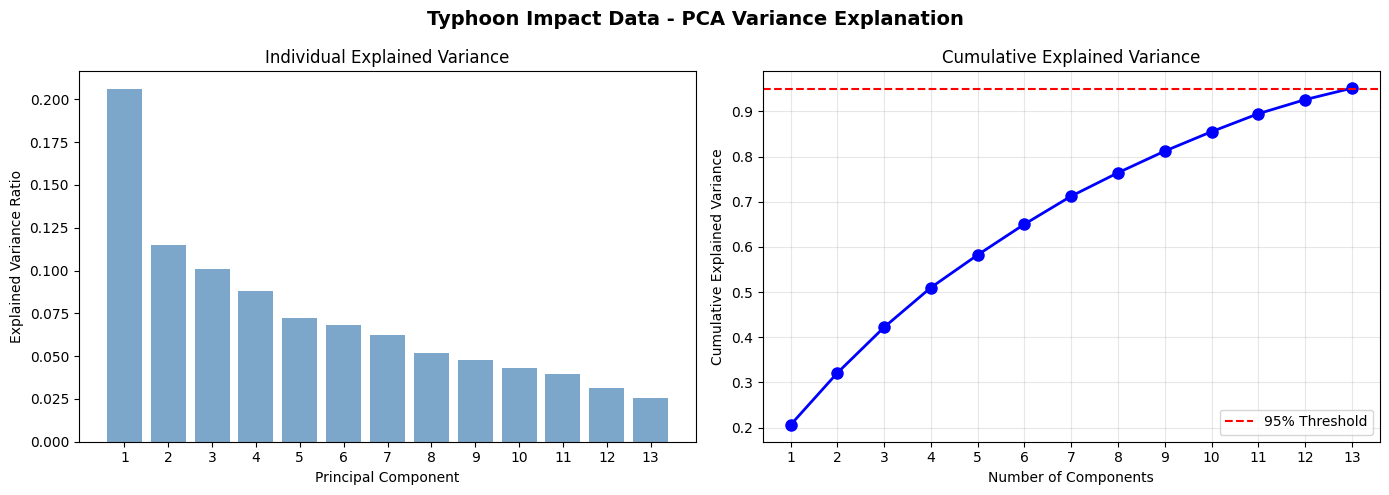

In [81]:
# Run PCA pipeline on typhoon impact data
typhoon_pca_results = run_complete_pca_pipeline(
    input_dataframe=df,
    n_components=None,  # Auto-determine based on variance threshold
    variance_threshold=0.95,
    categorical_columns=None,  # Include all columns (typhoon_type is now ordinal encoded)
    show_plots=True,
    return_loadings=True
)

In [82]:
# Access PCA results
typhoon_pca_df = typhoon_pca_results['pca_dataframe']

# Display explained variance information
print("=" * 60)
print("PCA EXPLAINED VARIANCE SUMMARY")
print("=" * 60)
print(f"Total samples: {len(typhoon_pca_df)}")
print(f"Number of PCA components: {typhoon_pca_df.shape[1]}")
print(f"Total variance explained: {typhoon_pca_results['total_variance_explained']*100:.2f}%")
print("\nVariance explained per component:")
for i, var in enumerate(typhoon_pca_results['explained_variance']):
    print(f"  PC{i+1}: {var*100:.2f}%")
print("=" * 60)

PCA EXPLAINED VARIANCE SUMMARY
Total samples: 1776
Number of PCA components: 13
Total variance explained: 95.15%

Variance explained per component:
  PC1: 20.61%
  PC2: 11.51%
  PC3: 10.11%
  PC4: 8.79%
  PC5: 7.23%
  PC6: 6.80%
  PC7: 6.21%
  PC8: 5.17%
  PC9: 4.79%
  PC10: 4.30%
  PC11: 3.98%
  PC12: 3.12%
  PC13: 2.53%


## Model Training and Evaluation (Baseline + Optuna-Optimized)

Train all 12 clustering models (6 baseline + 6 Optuna-optimized) and compute evaluation metrics. All models are configured to produce exactly **3 clusters**.

In [83]:
# Import additional clustering algorithms
from sklearn.cluster import AgglomerativeClustering, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
import time

# Get PCA data for clustering
X_pca = typhoon_pca_df.values

# Dictionary to store model labels and metrics
model_labels = {}
model_metrics = []

# Fixed number of clusters for ALL models (including DBSCAN targeting)
n_clusters = 3

print("="*80)
print("TRAINING 12 CLUSTERING MODELS (6 BASELINE + 6 OPTUNA-OPTIMIZED, 3 CLUSTERS)")
print("="*80)

TRAINING 12 CLUSTERING MODELS (6 BASELINE + 6 OPTUNA-OPTIMIZED, 3 CLUSTERS)


### Baseline Models (Default Parameters)

In [84]:
# 1. KMeans (Baseline - Default Parameters)
print("\n1. Training KMeans (Baseline)...")

start_time = time.time()
kmeans_baseline = KMeans(n_clusters=n_clusters, random_state=42)
model_labels['KMeans (Baseline)'] = kmeans_baseline.fit_predict(X_pca)
kmeans_baseline_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['KMeans (Baseline)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['KMeans (Baseline)'])
db_score = davies_bouldin_score(X_pca, model_labels['KMeans (Baseline)'])

model_metrics.append({
    'model': 'KMeans (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': kmeans_baseline_time
})
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


1. Training KMeans (Baseline)...
   Silhouette: 0.1446, Calinski-H: 248.69, Davies-B: 2.0063


In [85]:
# 2. DBSCAN (Baseline - Default Parameters)
print("\n2. Training DBSCAN (Baseline)...")

start_time = time.time()
dbscan_baseline = DBSCAN(eps=0.5, min_samples=5)
model_labels['DBSCAN (Baseline)'] = dbscan_baseline.fit_predict(X_pca)
dbscan_baseline_time = time.time() - start_time

# Calculate metrics (excluding noise points for silhouette)
dbscan_baseline_labels = model_labels['DBSCAN (Baseline)']
mask = dbscan_baseline_labels != -1
n_clusters_dbscan_baseline = len(set(dbscan_baseline_labels)) - (1 if -1 in dbscan_baseline_labels else 0)

if np.sum(mask) >= 2 and n_clusters_dbscan_baseline >= 2:
    sil_score = silhouette_score(X_pca[mask], dbscan_baseline_labels[mask])
    ch_score = calinski_harabasz_score(X_pca[mask], dbscan_baseline_labels[mask])
    db_score = davies_bouldin_score(X_pca[mask], dbscan_baseline_labels[mask])
else:
    sil_score, ch_score, db_score = 0, 0, float('inf')

model_metrics.append({
    'model': 'DBSCAN (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters_dbscan_baseline,
    'time': dbscan_baseline_time
})
print(f"   Clusters found: {n_clusters_dbscan_baseline}, Noise points: {np.sum(~mask)}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


2. Training DBSCAN (Baseline)...

   Clusters found: 61, Noise points: 554
   Silhouette: 0.5833, Calinski-H: 818.22, Davies-B: 0.6005
   Clusters found: 61, Noise points: 554
   Silhouette: 0.5833, Calinski-H: 818.22, Davies-B: 0.6005


In [86]:
# 3. Agglomerative Ward (Baseline)
print("\n3. Training Agglomerative Ward (Baseline)...")

start_time = time.time()
agglo_ward_baseline = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
model_labels['Agglomerative Ward (Baseline)'] = agglo_ward_baseline.fit_predict(X_pca)
agglo_ward_baseline_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['Agglomerative Ward (Baseline)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['Agglomerative Ward (Baseline)'])
db_score = davies_bouldin_score(X_pca, model_labels['Agglomerative Ward (Baseline)'])

model_metrics.append({
    'model': 'Agglomerative Ward (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': agglo_ward_baseline_time
})
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


3. Training Agglomerative Ward (Baseline)...
   Silhouette: 0.1607, Calinski-H: 228.00, Davies-B: 2.0300
   Silhouette: 0.1607, Calinski-H: 228.00, Davies-B: 2.0300


In [87]:
# 4. Agglomerative Complete (Baseline)
print("\n4. Training Agglomerative Complete (Baseline)...")

start_time = time.time()
agglo_complete_baseline = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete', metric='euclidean')
model_labels['Agglomerative Complete (Baseline)'] = agglo_complete_baseline.fit_predict(X_pca)
agglo_complete_baseline_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['Agglomerative Complete (Baseline)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['Agglomerative Complete (Baseline)'])
db_score = davies_bouldin_score(X_pca, model_labels['Agglomerative Complete (Baseline)'])

model_metrics.append({
    'model': 'Agglomerative Complete (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': agglo_complete_baseline_time
})
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


4. Training Agglomerative Complete (Baseline)...


   Silhouette: 0.8414, Calinski-H: 99.51, Davies-B: 0.3622


In [88]:
# 5. GMM Full (Baseline)
print("\n5. Training GMM Full (Baseline)...")

start_time = time.time()
gmm_full_baseline = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
model_labels['GMM Full (Baseline)'] = gmm_full_baseline.fit_predict(X_pca)
gmm_full_baseline_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['GMM Full (Baseline)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['GMM Full (Baseline)'])
db_score = davies_bouldin_score(X_pca, model_labels['GMM Full (Baseline)'])

model_metrics.append({
    'model': 'GMM Full (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': gmm_full_baseline_time
})
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


5. Training GMM Full (Baseline)...
   Silhouette: 0.1156, Calinski-H: 140.38, Davies-B: 2.5653
   Silhouette: 0.1156, Calinski-H: 140.38, Davies-B: 2.5653


In [89]:
# 6. GMM Diag (Baseline)
print("\n6. Training GMM Diag (Baseline)...")

start_time = time.time()
gmm_diag_baseline = GaussianMixture(n_components=n_clusters, covariance_type='diag', random_state=42)
model_labels['GMM Diag (Baseline)'] = gmm_diag_baseline.fit_predict(X_pca)
gmm_diag_baseline_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['GMM Diag (Baseline)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['GMM Diag (Baseline)'])
db_score = davies_bouldin_score(X_pca, model_labels['GMM Diag (Baseline)'])

model_metrics.append({
    'model': 'GMM Diag (Baseline)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': gmm_diag_baseline_time
})
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")

print("\n" + "="*80)
print("ALL 6 BASELINE MODELS TRAINED!")
print("="*80)


6. Training GMM Diag (Baseline)...
   Silhouette: 0.1342, Calinski-H: 188.18, Davies-B: 1.9677

ALL 6 BASELINE MODELS TRAINED!


### Optuna-Optimized Models

In [90]:
# 7. KMeans (Optuna-optimized)
print("\n7. Training KMeans (Optuna)...")

def kmeans_objective(trial):
    init = trial.suggest_categorical('init', ['k-means++', 'random'])
    n_init = trial.suggest_int('n_init', 10, 50)
    max_iter = trial.suggest_int('max_iter', 100, 500)
    
    kmeans = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, max_iter=max_iter, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    return silhouette_score(X_pca, labels)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_kmeans = optuna.create_study(direction='maximize')
study_kmeans.optimize(kmeans_objective, n_trials=30, show_progress_bar=False)

start_time = time.time()
best_params = study_kmeans.best_params
kmeans_optuna = KMeans(n_clusters=n_clusters, **best_params, random_state=42)
model_labels['KMeans (Optuna)'] = kmeans_optuna.fit_predict(X_pca)
kmeans_optuna_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['KMeans (Optuna)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['KMeans (Optuna)'])
db_score = davies_bouldin_score(X_pca, model_labels['KMeans (Optuna)'])

model_metrics.append({
    'model': 'KMeans (Optuna)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': kmeans_optuna_time
})
print(f"   Best params: {best_params}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


7. Training KMeans (Optuna)...

   Best params: {'init': 'k-means++', 'n_init': 43, 'max_iter': 283}
   Silhouette: 0.1636, Calinski-H: 250.23, Davies-B: 1.9646
   Best params: {'init': 'k-means++', 'n_init': 43, 'max_iter': 283}
   Silhouette: 0.1636, Calinski-H: 250.23, Davies-B: 1.9646


In [91]:
# 8. DBSCAN (Optuna-optimized to target 3 clusters)
print("\n8. Training DBSCAN (Optuna) - Targeting 3 Clusters...")

def dbscan_objective(trial):
    eps = trial.suggest_float('eps', 0.1, 10.0)
    min_samples = trial.suggest_int('min_samples', 2, 30)
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca)
    
    # Count clusters (excluding noise)
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Strongly prefer exactly 3 clusters
    if n_clusters_found != 3:
        return -1 - abs(n_clusters_found - 3)  # Penalty based on distance from 3
    
    # Calculate silhouette only on non-noise points
    mask = labels != -1
    if np.sum(mask) < 10:
        return -1
    
    return silhouette_score(X_pca[mask], labels[mask])

study_dbscan = optuna.create_study(direction='maximize')
study_dbscan.optimize(dbscan_objective, n_trials=100, show_progress_bar=False)

start_time = time.time()
best_params_dbscan = study_dbscan.best_params
dbscan_optuna = DBSCAN(**best_params_dbscan)
model_labels['DBSCAN (Optuna)'] = dbscan_optuna.fit_predict(X_pca)
dbscan_time = time.time() - start_time

# Calculate metrics (excluding noise points for silhouette)
dbscan_labels = model_labels['DBSCAN (Optuna)']
mask = dbscan_labels != -1
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if np.sum(mask) >= 2 and n_clusters_dbscan >= 2:
    sil_score = silhouette_score(X_pca[mask], dbscan_labels[mask])
    ch_score = calinski_harabasz_score(X_pca[mask], dbscan_labels[mask])
    db_score = davies_bouldin_score(X_pca[mask], dbscan_labels[mask])
else:
    sil_score, ch_score, db_score = 0, 0, float('inf')

model_metrics.append({
    'model': 'DBSCAN (Optuna)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters_dbscan,
    'time': dbscan_time
})
print(f"   Best params: {best_params_dbscan}")
print(f"   Clusters found: {n_clusters_dbscan}, Noise points: {np.sum(~mask)}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


8. Training DBSCAN (Optuna) - Targeting 3 Clusters...
   Best params: {'eps': 5.544917249142482, 'min_samples': 2}
   Clusters found: 3, Noise points: 20
   Silhouette: 0.5388, Calinski-H: 48.03, Davies-B: 0.5203
   Best params: {'eps': 5.544917249142482, 'min_samples': 2}
   Clusters found: 3, Noise points: 20
   Silhouette: 0.5388, Calinski-H: 48.03, Davies-B: 0.5203


In [92]:
# 9. Agglomerative Clustering (Optuna-optimized - Ward linkage, Fixed 3 Clusters)
print("\n9. Training Agglomerative Ward (Optuna) - Fixed 3 Clusters...")

# Ward linkage with fixed 3 clusters
start_time = time.time()
agglo_ward = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
model_labels['Agglomerative Ward (Optuna)'] = agglo_ward.fit_predict(X_pca)
agglo_ward_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['Agglomerative Ward (Optuna)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['Agglomerative Ward (Optuna)'])
db_score = davies_bouldin_score(X_pca, model_labels['Agglomerative Ward (Optuna)'])

model_metrics.append({
    'model': 'Agglomerative Ward (Optuna)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': agglo_ward_time
})
print(f"   n_clusters: {n_clusters}, linkage: ward")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


9. Training Agglomerative Ward (Optuna) - Fixed 3 Clusters...
   n_clusters: 3, linkage: ward
   Silhouette: 0.1607, Calinski-H: 228.00, Davies-B: 2.0300
   n_clusters: 3, linkage: ward
   Silhouette: 0.1607, Calinski-H: 228.00, Davies-B: 2.0300


In [93]:
# 10. Agglomerative Clustering (Optuna-optimized - Complete linkage, Fixed 3 Clusters)
print("\n10. Training Agglomerative Complete (Optuna) - Fixed 3 Clusters...")

def agglo_complete_objective(trial):
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine'])
    
    agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete', metric=metric)
    labels = agglo.fit_predict(X_pca)
    return silhouette_score(X_pca, labels)

study_agglo_complete = optuna.create_study(direction='maximize')
study_agglo_complete.optimize(agglo_complete_objective, n_trials=30, show_progress_bar=False)

start_time = time.time()
best_params_complete = study_agglo_complete.best_params
agglo_complete = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='complete',
    metric=best_params_complete['metric']
)
model_labels['Agglomerative Complete (Optuna)'] = agglo_complete.fit_predict(X_pca)
agglo_complete_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['Agglomerative Complete (Optuna)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['Agglomerative Complete (Optuna)'])
db_score = davies_bouldin_score(X_pca, model_labels['Agglomerative Complete (Optuna)'])

model_metrics.append({
    'model': 'Agglomerative Complete (Optuna)',
    'silhouette': sil_score,
    'calinski_harabasz': ch_score,
    'davies_bouldin': db_score,
    'n_clusters': n_clusters,
    'time': agglo_complete_time
})
print(f"   Best params: {best_params_complete}")
print(f"   n_clusters: {n_clusters}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


10. Training Agglomerative Complete (Optuna) - Fixed 3 Clusters...


   Best params: {'metric': 'manhattan'}
   n_clusters: 3
   Silhouette: 0.8414, Calinski-H: 99.51, Davies-B: 0.3622


In [94]:
# 11. Gaussian Mixture Model (Optuna-optimized - Full covariance, Fixed 3 Clusters)
print("\n11. Training GMM Full (Optuna) - Fixed 3 Clusters...")

def gmm_full_objective(trial):
    n_init = trial.suggest_int('n_init', 1, 10)
    max_iter = trial.suggest_int('max_iter', 100, 500)
    reg_covar = trial.suggest_float('reg_covar', 1e-7, 1e-3, log=True)
    init_params = trial.suggest_categorical('init_params', ['kmeans', 'k-means++', 'random'])
    
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full',
                          n_init=n_init, max_iter=max_iter, reg_covar=reg_covar,
                          init_params=init_params, random_state=42)
    labels = gmm.fit_predict(X_pca)
    return silhouette_score(X_pca, labels)

study_gmm_full = optuna.create_study(direction='maximize')
study_gmm_full.optimize(gmm_full_objective, n_trials=30, show_progress_bar=False)

start_time = time.time()
best_params_gmm_full = study_gmm_full.best_params
gmm_full = GaussianMixture(n_components=n_clusters, covariance_type='full',
    n_init=best_params_gmm_full['n_init'], max_iter=best_params_gmm_full['max_iter'],
    reg_covar=best_params_gmm_full['reg_covar'], init_params=best_params_gmm_full['init_params'], random_state=42)
model_labels['GMM Full (Optuna)'] = gmm_full.fit_predict(X_pca)
gmm_full_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['GMM Full (Optuna)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['GMM Full (Optuna)'])
db_score = davies_bouldin_score(X_pca, model_labels['GMM Full (Optuna)'])

model_metrics.append({'model': 'GMM Full (Optuna)', 'silhouette': sil_score, 'calinski_harabasz': ch_score,
    'davies_bouldin': db_score, 'n_clusters': n_clusters, 'time': gmm_full_time})
print(f"   Best params: {best_params_gmm_full}")
print(f"   n_clusters: {n_clusters}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")


11. Training GMM Full (Optuna) - Fixed 3 Clusters...
   Best params: {'n_init': 2, 'max_iter': 208, 'reg_covar': 0.00014293272519417844, 'init_params': 'random'}
   n_clusters: 3
   Silhouette: 0.2403, Calinski-H: 99.40, Davies-B: 3.3809
   Best params: {'n_init': 2, 'max_iter': 208, 'reg_covar': 0.00014293272519417844, 'init_params': 'random'}
   n_clusters: 3
   Silhouette: 0.2403, Calinski-H: 99.40, Davies-B: 3.3809


In [95]:
# 12. Gaussian Mixture Model (Optuna-optimized - Diagonal covariance, Fixed 3 Clusters)
print("\n12. Training GMM Diag (Optuna) - Fixed 3 Clusters...")

def gmm_diag_objective(trial):
    n_init = trial.suggest_int('n_init', 1, 10)
    max_iter = trial.suggest_int('max_iter', 100, 500)
    reg_covar = trial.suggest_float('reg_covar', 1e-7, 1e-3, log=True)
    init_params = trial.suggest_categorical('init_params', ['kmeans', 'k-means++', 'random'])
    
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='diag',
                          n_init=n_init, max_iter=max_iter, reg_covar=reg_covar,
                          init_params=init_params, random_state=42)
    labels = gmm.fit_predict(X_pca)
    return silhouette_score(X_pca, labels)

study_gmm_diag = optuna.create_study(direction='maximize')
study_gmm_diag.optimize(gmm_diag_objective, n_trials=30, show_progress_bar=False)

start_time = time.time()
best_params_gmm_diag = study_gmm_diag.best_params
gmm_diag = GaussianMixture(n_components=n_clusters, covariance_type='diag',
    n_init=best_params_gmm_diag['n_init'], max_iter=best_params_gmm_diag['max_iter'],
    reg_covar=best_params_gmm_diag['reg_covar'], init_params=best_params_gmm_diag['init_params'], random_state=42)
model_labels['GMM Diag (Optuna)'] = gmm_diag.fit_predict(X_pca)
gmm_diag_time = time.time() - start_time

sil_score = silhouette_score(X_pca, model_labels['GMM Diag (Optuna)'])
ch_score = calinski_harabasz_score(X_pca, model_labels['GMM Diag (Optuna)'])
db_score = davies_bouldin_score(X_pca, model_labels['GMM Diag (Optuna)'])

model_metrics.append({'model': 'GMM Diag (Optuna)', 'silhouette': sil_score, 'calinski_harabasz': ch_score,
    'davies_bouldin': db_score, 'n_clusters': n_clusters, 'time': gmm_diag_time})
print(f"   Best params: {best_params_gmm_diag}")
print(f"   n_clusters: {n_clusters}")
print(f"   Silhouette: {sil_score:.4f}, Calinski-H: {ch_score:.2f}, Davies-B: {db_score:.4f}")

print("\n" + "="*70)
print("ALL 6 MODELS TRAINED WITH OPTUNA OPTIMIZATION (3 CLUSTERS)!")
print("="*70)


12. Training GMM Diag (Optuna) - Fixed 3 Clusters...
   Best params: {'n_init': 1, 'max_iter': 359, 'reg_covar': 6.178995829495238e-07, 'init_params': 'random'}
   n_clusters: 3
   Silhouette: 0.2090, Calinski-H: 172.51, Davies-B: 2.5814

ALL 6 MODELS TRAINED WITH OPTUNA OPTIMIZATION (3 CLUSTERS)!
   Best params: {'n_init': 1, 'max_iter': 359, 'reg_covar': 6.178995829495238e-07, 'init_params': 'random'}
   n_clusters: 3
   Silhouette: 0.2090, Calinski-H: 172.51, Davies-B: 2.5814

ALL 6 MODELS TRAINED WITH OPTUNA OPTIMIZATION (3 CLUSTERS)!


In [96]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(model_metrics)
comparison_subset = comparison_df.copy()

# Display comparison table
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))

# Calculate combined normalized score
# Normalize each metric to 0-1 scale
sil_norm = (comparison_subset['silhouette'] - comparison_subset['silhouette'].min()) / (comparison_subset['silhouette'].max() - comparison_subset['silhouette'].min() + 1e-10)
ch_norm = (comparison_subset['calinski_harabasz'] - comparison_subset['calinski_harabasz'].min()) / (comparison_subset['calinski_harabasz'].max() - comparison_subset['calinski_harabasz'].min() + 1e-10)
db_norm = 1 - (comparison_subset['davies_bouldin'] - comparison_subset['davies_bouldin'].min()) / (comparison_subset['davies_bouldin'].max() - comparison_subset['davies_bouldin'].min() + 1e-10)

# Combined score (equal weights)
combined_score = (sil_norm + ch_norm + db_norm) / 3
comparison_subset['combined_score'] = combined_score

print("\n" + "="*80)
print("NORMALIZED SCORES")
print("="*80)
print(comparison_subset[['model', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'combined_score']].sort_values('combined_score', ascending=False).to_string(index=False))


MODEL COMPARISON SUMMARY
                            model  silhouette  calinski_harabasz  davies_bouldin  n_clusters     time
                KMeans (Baseline)    0.144570         248.693285        2.006261           3 0.036673
                DBSCAN (Baseline)    0.583307         818.224003        0.600483          61 0.132441
    Agglomerative Ward (Baseline)    0.160691         228.004959        2.029980           3 0.131803
Agglomerative Complete (Baseline)    0.841416          99.512921        0.362249           3 0.113955
              GMM Full (Baseline)    0.115624         140.376247        2.565342           3 0.177220
              GMM Diag (Baseline)    0.134155         188.177885        1.967722           3 0.047997
                  KMeans (Optuna)    0.163625         250.229569        1.964563           3 0.159574
                  DBSCAN (Optuna)    0.538817          48.030952        0.520294           3 0.228894
      Agglomerative Ward (Optuna)    0.160691         22

## Plotting 2D and 3D

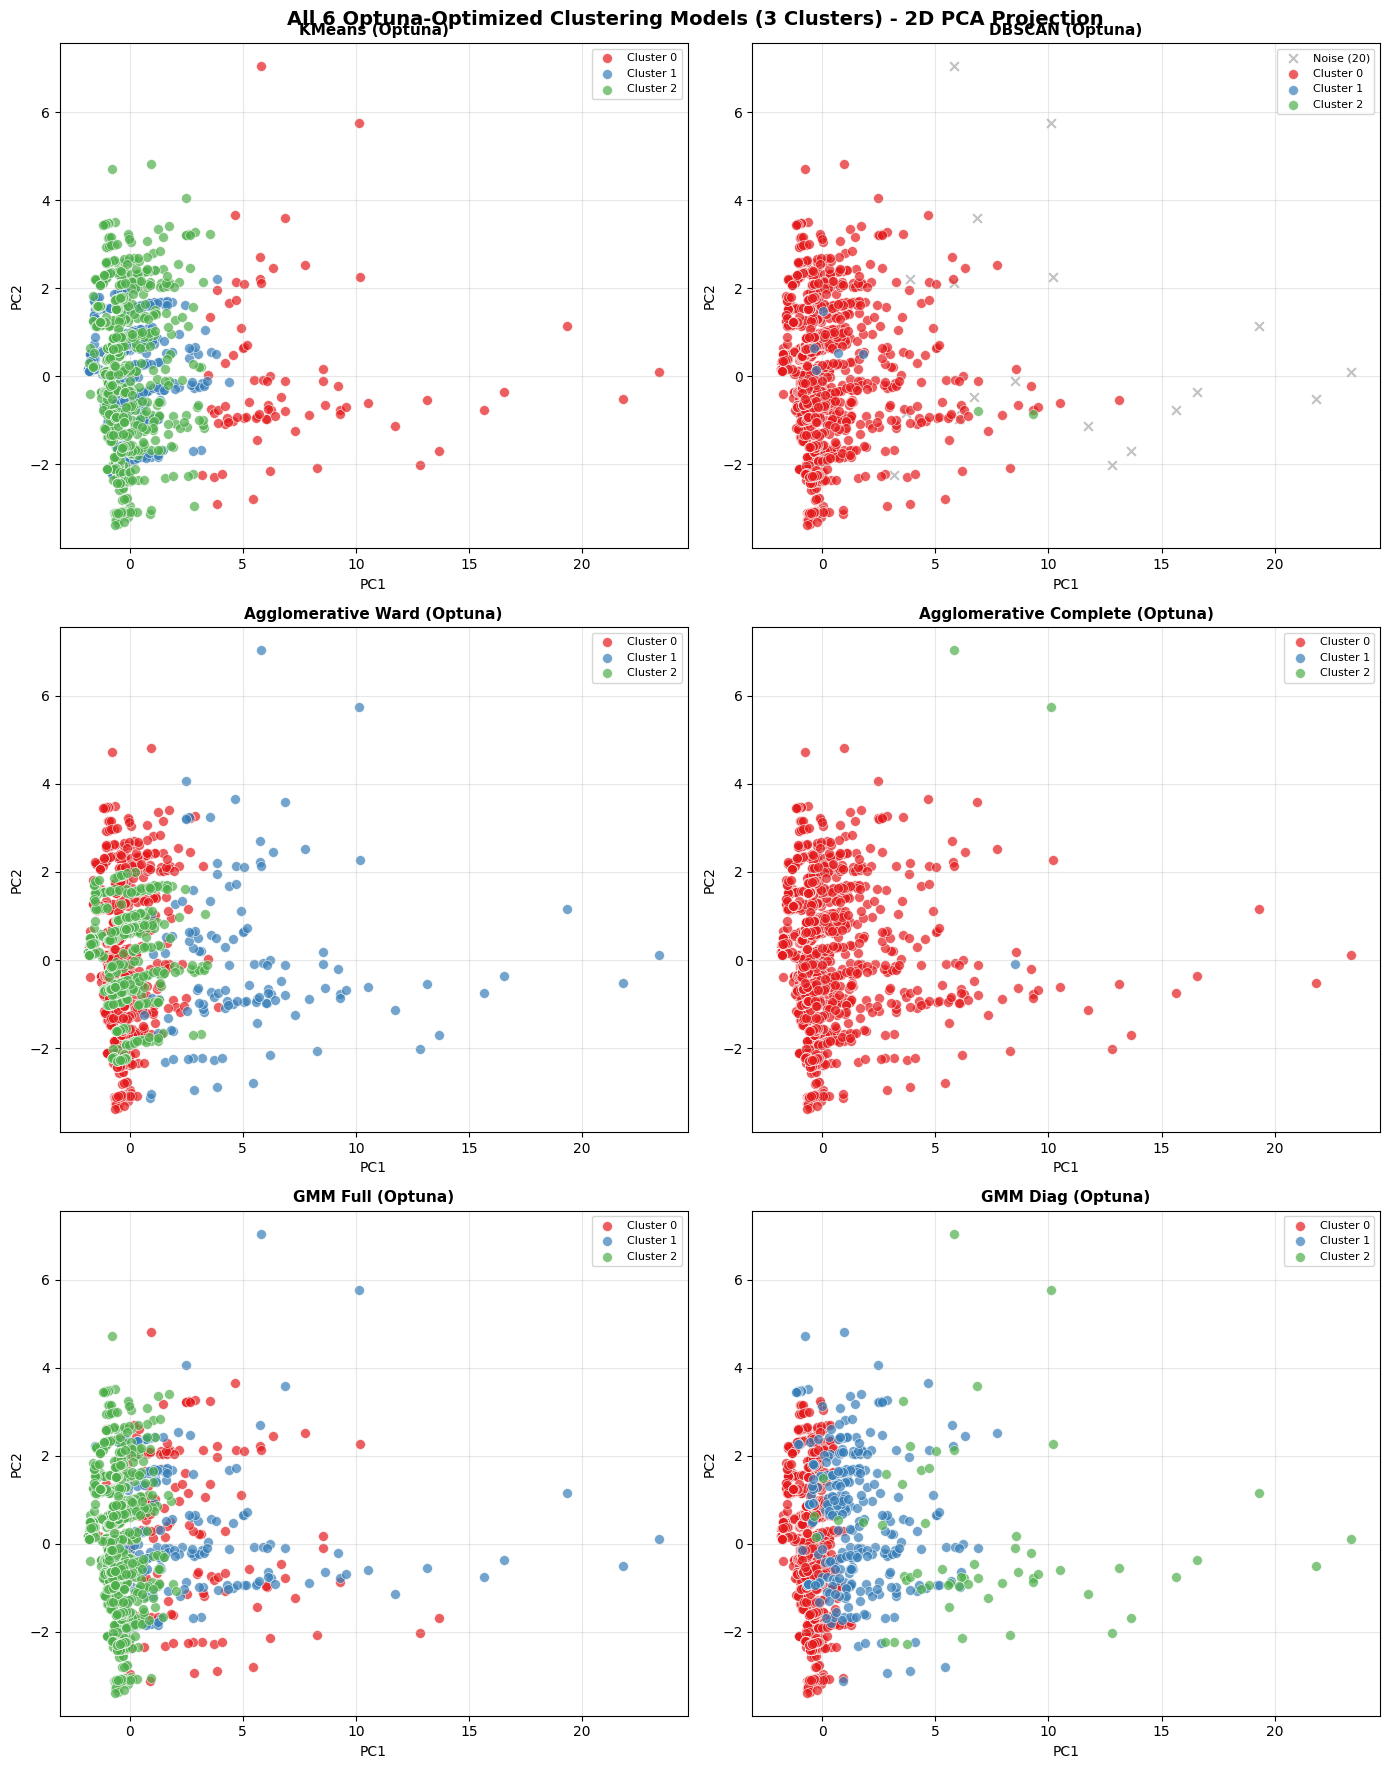

In [97]:
# Visualize cluster assignments from all 6 Optuna-optimized models (2D PCA)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# All 6 Optuna-optimized models
models_to_plot = [
    ('KMeans (Optuna)', model_labels['KMeans (Optuna)']),
    ('DBSCAN (Optuna)', model_labels['DBSCAN (Optuna)']),
    ('Agglomerative Ward (Optuna)', model_labels['Agglomerative Ward (Optuna)']),
    ('Agglomerative Complete (Optuna)', model_labels['Agglomerative Complete (Optuna)']),
    ('GMM Full (Optuna)', model_labels['GMM Full (Optuna)']),
    ('GMM Diag (Optuna)', model_labels['GMM Diag (Optuna)'])
]

# Get PCA components for visualization
pca_vis = typhoon_pca_df[['PC1', 'PC2']].values

# Define highly distinguishable colors for 3 clusters + noise
cluster_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

for idx, (model_name, labels) in enumerate(models_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    unique_labels = np.unique(labels)
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        if label == -1:  # Noise points for DBSCAN
            ax.scatter(pca_vis[mask, 0], pca_vis[mask, 1],
                      c='#999999', marker='x', s=40, alpha=0.6, label=f'Noise ({np.sum(mask)})')
        else:
            color = cluster_colors[label % len(cluster_colors)]
            ax.scatter(pca_vis[mask, 0], pca_vis[mask, 1],
                      c=color, s=50, alpha=0.7, label=f'Cluster {label}', edgecolors='white', linewidth=0.5)
    
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('All 6 Optuna-Optimized Clustering Models (3 Clusters) - 2D PCA Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close(fig)

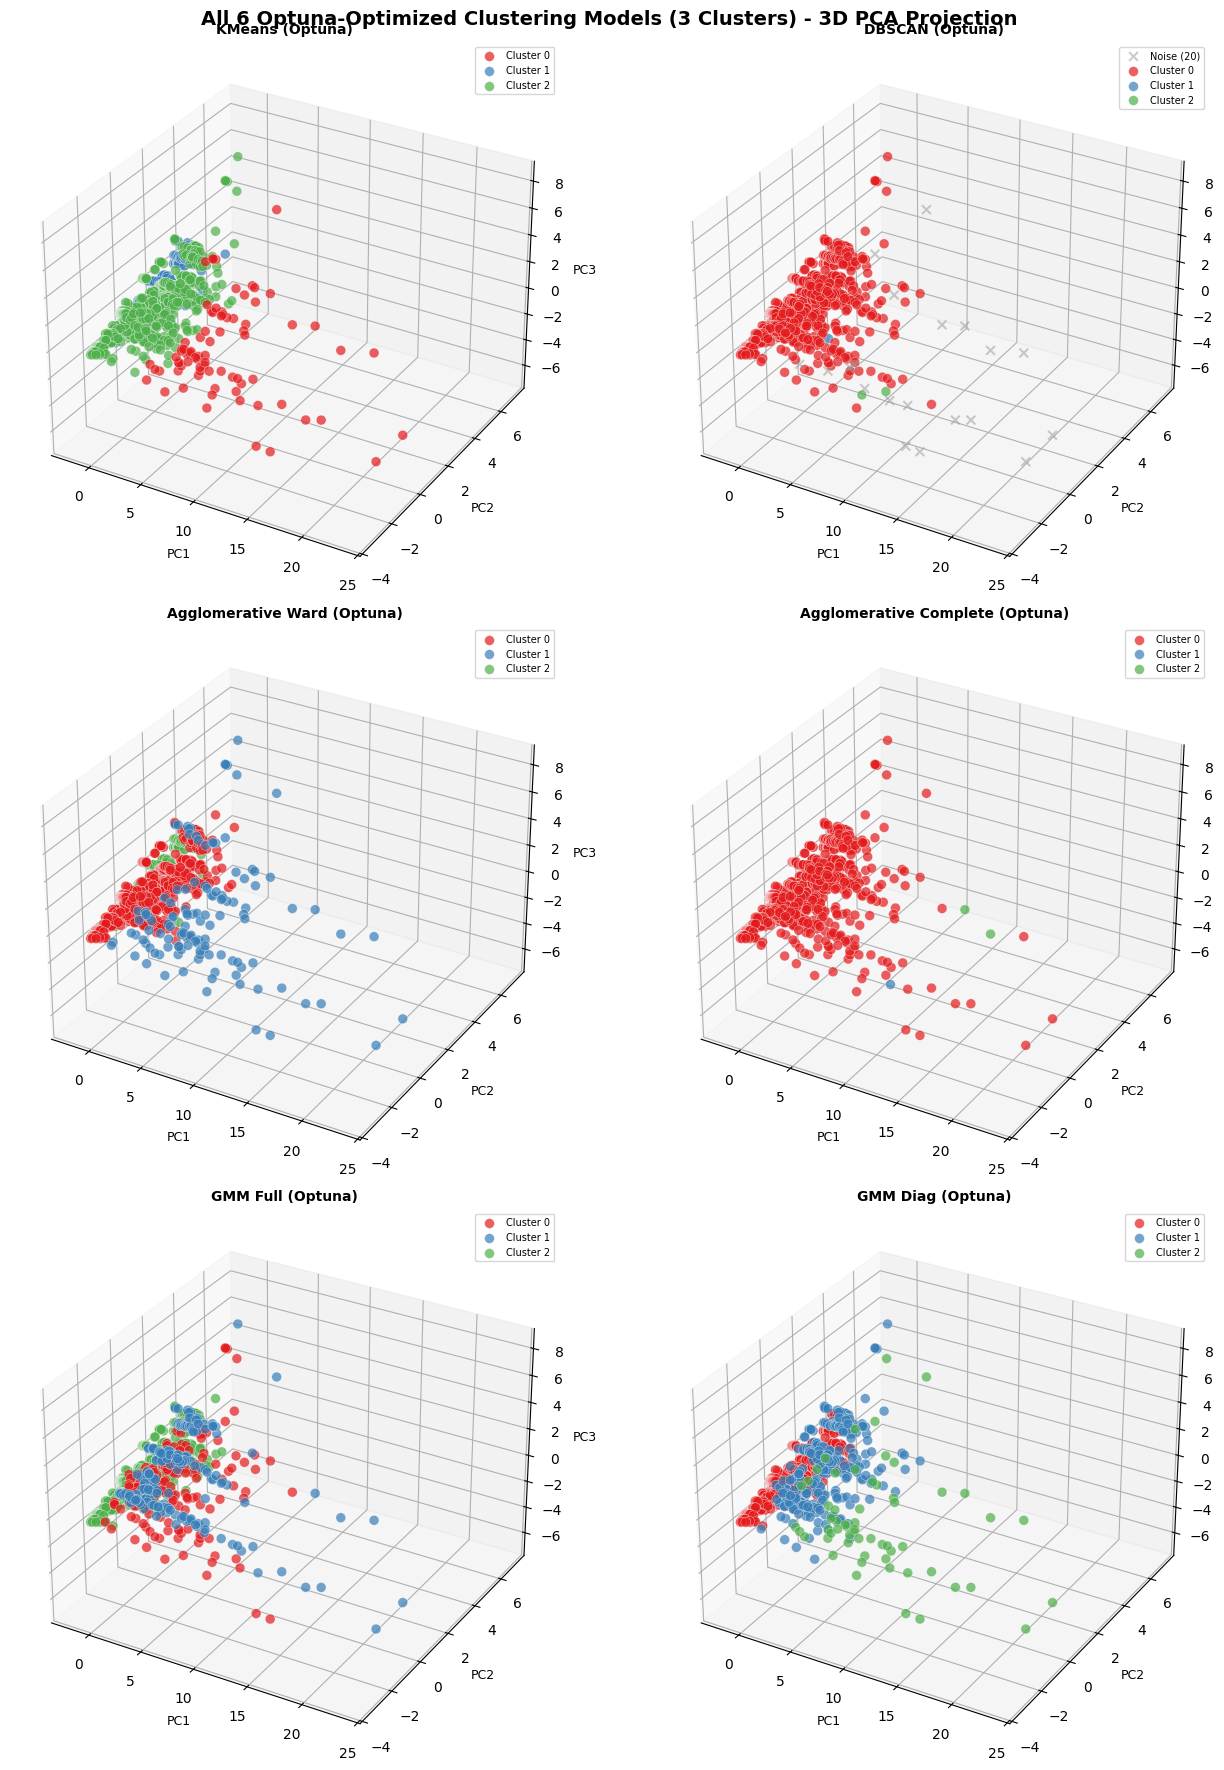

In [98]:
# 3D PCA Visualization Comparison - All 6 Optuna-Optimized Models
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 18))

# All 6 Optuna-optimized models
models_to_plot_3d = [
    ('KMeans (Optuna)', model_labels['KMeans (Optuna)']),
    ('DBSCAN (Optuna)', model_labels['DBSCAN (Optuna)']),
    ('Agglomerative Ward (Optuna)', model_labels['Agglomerative Ward (Optuna)']),
    ('Agglomerative Complete (Optuna)', model_labels['Agglomerative Complete (Optuna)']),
    ('GMM Full (Optuna)', model_labels['GMM Full (Optuna)']),
    ('GMM Diag (Optuna)', model_labels['GMM Diag (Optuna)'])
]

# Get PCA components for 3D visualization
pca_3d_vis = typhoon_pca_df[['PC1', 'PC2', 'PC3']].values

# Define highly distinguishable colors for 3 clusters + noise
cluster_colors_3d = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628', '#f781bf']

for idx, (model_name, labels) in enumerate(models_to_plot_3d):
    ax = fig.add_subplot(3, 2, idx + 1, projection='3d')
    
    unique_labels = np.unique(labels)
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        if label == -1:  # Noise points for DBSCAN
            ax.scatter(pca_3d_vis[mask, 0], pca_3d_vis[mask, 1], pca_3d_vis[mask, 2],
                      c='#999999', marker='x', s=40, alpha=0.5, label=f'Noise ({np.sum(mask)})')
        else:
            color = cluster_colors_3d[label % len(cluster_colors_3d)]
            ax.scatter(pca_3d_vis[mask, 0], pca_3d_vis[mask, 1], pca_3d_vis[mask, 2],
                      c=color, s=50, alpha=0.7, label=f'Cluster {label}', edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.set_zlabel('PC3', fontsize=9)
    ax.set_title(f'{model_name}', fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=7)

plt.suptitle('All 6 Optuna-Optimized Clustering Models (3 Clusters) - 3D PCA Projection', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
plt.close(fig)

In [99]:
# Final Model Ranking with All 6 Key Models
print("=" * 80)
print("FINAL MODEL RANKING - ALL 6 KEY MODELS")
print("=" * 80)

# Recalculate combined scores for final ranking
final_ranking = comparison_subset.copy()
final_ranking['combined_score'] = combined_score
final_ranking = final_ranking.sort_values('combined_score', ascending=False)

print("\nRanking by Combined Normalized Score:")
print("-" * 80)
for rank, (_, row) in enumerate(final_ranking.iterrows(), 1):
    print(f"{rank}. {row['model']}")
    print(f"   Silhouette: {row['silhouette']:.4f} | Calinski-H: {row['calinski_harabasz']:.2f} | Davies-B: {row['davies_bouldin']:.4f}")
    print()

FINAL MODEL RANKING - ALL 6 KEY MODELS

Ranking by Combined Normalized Score:
--------------------------------------------------------------------------------
1. DBSCAN (Baseline)
   Silhouette: 0.5833 | Calinski-H: 818.22 | Davies-B: 0.6005

2. Agglomerative Complete (Baseline)
   Silhouette: 0.8414 | Calinski-H: 99.51 | Davies-B: 0.3622

3. Agglomerative Complete (Optuna)
   Silhouette: 0.8414 | Calinski-H: 99.51 | Davies-B: 0.3622

4. DBSCAN (Optuna)
   Silhouette: 0.5388 | Calinski-H: 48.03 | Davies-B: 0.5203

5. KMeans (Optuna)
   Silhouette: 0.1636 | Calinski-H: 250.23 | Davies-B: 1.9646

6. KMeans (Baseline)
   Silhouette: 0.1446 | Calinski-H: 248.69 | Davies-B: 2.0063

7. Agglomerative Ward (Baseline)
   Silhouette: 0.1607 | Calinski-H: 228.00 | Davies-B: 2.0300

8. Agglomerative Ward (Optuna)
   Silhouette: 0.1607 | Calinski-H: 228.00 | Davies-B: 2.0300

9. GMM Diag (Baseline)
   Silhouette: 0.1342 | Calinski-H: 188.18 | Davies-B: 1.9677

10. GMM Diag (Optuna)
   Silhouette: 0